# Global sensitivity analysis: Michaelis-Menten kinetics, double binding 

Nathaniel Linden (UCSD MAE) - March  2023

In [1]:
import sunode
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import sympy as sym
from SALib.sample import sobol as sobol_samp
from SALib.sample import morris as morris_samp
from SALib.analyze import sobol as sobol_analyze
from SALib.analyze import morris as morris_analyze
import sys
import time
sys.path.insert(0, '../odes')

import ampk_MM_double_mech as model1
%matplotlib inline
plt.style.use('~/.matplotlib/custom.mplstyle')
mpl.rcParams['figure.autolayout'] = True

## Defining bounds for the parameters and unknown initial conditions
Notes:
- Will only vary $K_{\rm d, AMP}$, $K_{\rm d, ADP}$, $K_{\rm d, ATP}$, and estimate forward and reverse rates by fixing the forward rate to 1 and setting the reverse rate accordingly. 
$$
    K_{\rm d} = k_f / k_r
$$
- Assume CamKK2 has a molecular weight of 60-90 kDA (https://www.thermofisher.com/order/catalog/product/PV4206). Thus Vmax varies from 0.286 /s to 0.429 /s. Assume that the total CaMKK2 concentration varies from $1\times 10^{-4}$  to $1\times 10^{-1}$ , thus $k_{\rm phos,CaMKK}$ varies from 28.6 1/s to 4290.0 1/s
- KmLKB1 varies from 1.0 to 5 mM (nominal is 1.4 mM)
- KmCaMKK2 varies from 1.0e-1 to 3e-2 mM (nominal is 1.5e-2)
- KmPP and KmPP1 vary from 5e-2 to 1e-1 mM
 - KmAMPK varies from 1e-3 to 1e-2
- Assume total LKB1 concentration varies from $1\times 10^{-5}$ mM to $1\times 10^{-1}$ 
- Assume total CamKK2 concentration varies from $1\times 10^{-4}$ mM to $1\times 10^{-1}$ mM
- Assume total PP concentration varies from $1\times 10^{-4}$ mM to $1\times 10^{-1}$ mM
- Assume total PP1 concentration varies from $1\times 10^{-4}$ mM to $1\times 10^{-1}$ mM
- Assume total AMPKAR concentration varies from $1\times 10^{-4}$ mM to $1\times 10^{-1}$ mM

In [2]:
# define the bounds for the parameters
# we use plus or minus on order of magnitude of any known values and then make resonable assumptions for unknowns
nominal_vals = [
   2.5e-3, # KdAMP
   1.5e-3, # KdADP
   1.7e-3, # KdATP
   0.357, # kPhosCaMKK
   1.5e-2,  # KmCaMKK
   3.92e-2, # kPhosLKB1
   1.4,  # KmLKB1
   1.1e-1, # kDephosPP
   6.7e-2, # KmPP
   6.33, # kPhosAMPK
   4.67e-3, # KmAMPK
   1.1e-1, # kDephosPP1
   6.7e-2, # KmPP1
   1e-3, # AMPKAR
]

# vary parameters by 50% and 20%
bounds_50 = [[0.5*param, 1.5*param] for param in nominal_vals]
bounds_90 = [[0.1*param, 1.9*param] for param in nominal_vals]

param_names = ['KdAMP', 'KdADP', 'KdATP', 'kPhosCaMKK', 'KmCamKK', 'kPhosLKB1', 'KmLKB1', 'kDephosPP', 'KmPP', 'kPhosAMPK', 'KmAMPK', 
               'kDephosPP1', 'KmPP1', 'AMPKAR']
state_names = ['AMP', 'ADP', 'ATP', 'AMPK', 'pAMPK', 'AMP_AMPK', 'ADP_AMPK', 'ATP_AMPK', 'AMP_pAMPK', 'ADP_pAMPK', 'ATP_pAMPK', 'AMP_AMP_AMPK', 'AMP_ADP_AMPK', 'AMP_ATP_AMPK', 'ADP_ADP_AMPK', 'ADP_ATP_AMPK', 'ATP_ATP_AMPK', 'AMP_AMP_pAMPK', 'AMP_ADP_pAMPK', 'AMP_ATP_pAMPK', 'ADP_ADP_pAMPK', 'ADP_ATP_pAMPK', 'ATP_ATP_pAMPK', 'AMPKAR', 'pAMPKAR']

# dictionary of the problem for SALib
problem_50 = {'num_vars':14, 'names':param_names, 'bounds': bounds_50,}
problem_90 = {'num_vars':14, 'names':param_names, 'bounds': bounds_90,}

seed = np.random.seed(seed=2048)

In [3]:
# initialize the initial condition dictionary
# Initial conditions
def set_init_conds(problem_ode, state_names):
    # Initial conditions
    y0 = np.zeros((), dtype=problem_ode.state_dtype)
    y0['AMP'] = 2e-5   # 'AMP' mM
    y0['ADP'] = 1.3e-1 # 'ADP mM
    y0['ATP'] = 8.2   # 'ATP mM
    y0['AMPK'] = 0.6   # 'AMPK mM
    y0['AMPKAR'] = 1e-3   # 'AMPKAR mM

    return y0

def single_model_eval(params, problem, solver, y0, tvals, state_names):

    # update relevant initial conditions 
    y0['AMPKAR'] = params[13]

    # NORMAL GLYCOLYSIS
    # set the parameters
    solver.set_params_dict({
        'kOnAMP': 1.0, # 1/(mM s) 
        'kOffAMP': params[0], # kr = Kd*kf
        'kOnADP': 1.0,
        'kOffADP': params[1], # kr = Kd*kf
        'kOnATP': 1.0, 
        'kOffATP': params[2], # kr = Kd*kf
        'kCaMKK': params[3], # CaMKK
        'KmCaMKK': params[4],
        'kLKB1': params[5], # LKB1 binding
        'KmLKB1': params[6],
        'kPP': params[7], # AMPK Phosphatase
        'KmPP': params[8],
        'kAMPK': params[9], # AMPK kinase
        'KmAMPK': params[10],
        'kPP1': params[11], # pAMPKAR Phosphatase
        'KmPP1': params[12],
        'kGly': 1300.0,
        'kHydro':1.4e-3,
        'kForAK':40.44,
        'kRevAK':1.1e-3,
        'VmaxOxPhos':0.5,
        'Kadp': 5.8e-2,
        'n': 2.568,
        'LKB1tot': 1.0,  
        'CaMKKtot': 1.0, 
        'PPtot': 1.0,
        'PP1tot': 1.0,
    })

    yout = solver.make_output_buffers(tvals)
    solver.solve(t0=0, tvals=tvals, y0=y0, y_out=yout)
    
    y0_new = np.zeros((), dtype=problem.state_dtype)
    for state in state_names:
        y0_new[state] = yout.view(problem.state_dtype)[state][-1]


    # PERTUBED GLYCOLYSIS
    # set the parameters
    solver.set_params_dict({
        'kOnAMP': 1.0, # 1/(mM s) 
        'kOffAMP': params[0], # kr = Kd*kf
        'kOnADP': 1.0,
        'kOffADP': params[1], # kr = Kd*kf
        'kOnATP': 1.0, 
        'kOffATP': params[2], # kr = Kd*kf
        'kCaMKK': params[3], # CaMKK
        'KmCaMKK': params[4],
        'kLKB1': params[5], # LKB1 binding
        'KmLKB1': params[6],
        'kPP': params[7], # AMPK Phosphatase
        'KmPP': params[8],
        'kAMPK': params[9], # AMPK kinase
        'KmAMPK': params[10],
        'kPP1': params[11], # pAMPKAR Phosphatase
        'KmPP1': params[12],
        'kGly': 4.5, # LOWER RATE!
        'kHydro':1.4e-3,
        'kForAK':40.44,
        'kRevAK':1.1e-3,
        'VmaxOxPhos':0.5,
        'Kadp': 5.8e-2,
        'n': 2.568,
        'LKB1tot': 1.0,  
        'CaMKKtot': 1.0, 
        'PPtot': 1.0,
        'PP1tot': 1.0,
    })
    # test
    yout1 = solver.make_output_buffers(tvals)
    solver.solve(t0=0, tvals=tvals, y0=y0_new, y_out=yout1)

    # now compute the output QoIs
    # pAMPKAR/AMPKAR steady-state before perturb
    pAMPKAR_AMPKAR_ss = yout.view(problem.state_dtype)['pAMPKAR'][-1] / yout.view(problem.state_dtype)['AMPKAR'][-1]

    # change after glycolysis perturbation
    pAMPKAR_AMPKAR_final_ss = yout1.view(problem.state_dtype)['pAMPKAR'][-1] / yout1.view(problem.state_dtype)['AMPKAR'][-1]
    pAMPKAR_AMPKAR_delta = pAMPKAR_AMPKAR_final_ss - pAMPKAR_AMPKAR_ss

    return np.array([pAMPKAR_AMPKAR_ss, pAMPKAR_AMPKAR_delta]), yout, yout1

In [5]:
# SET UP problem and SOLVER
# load the necessary dictionaries
params = model1.ampk_MM_double_mech_get_params()
states = model1.ampk_MM_double_mech_get_states()
nparams = len(params)
nstates = len(states)

# create sunode problem
problem_ode = sunode.SympyProblem(
    params=params,
    states=states,
    rhs_sympy=model1.ampk_MM_double_mech_RHS,
    # specify variables to take gradients wrt
    derivative_params=(),
)

# solver
solver = sunode.solver.Solver(problem_ode, solver='BDF')
lib = sunode._cvodes.lib
lib.CVodeSetMaxNumSteps(solver._ode, 5000) # increase max steps

y0 = set_init_conds(problem_ode, state_names)

 # evaluate the solution at these times
tvals = np.linspace(0, 3000, 1000)


In [7]:
# generate samples using the Saltelli and Morris sampling methods
# plot resulting solutions to see if the ranges make sense
nsamps = 16
param_vals_sobol = sobol_samp.sample(problem_90, nsamps, calc_second_order=True, seed=seed)
param_vals_morris = morris_samp.sample(problem_90, nsamps, seed=seed)

sols_sobol = [single_model_eval(param, problem_ode, 
                      solver, set_init_conds(problem_ode, state_names), 
                      tvals, state_names) for param in param_vals_sobol]

sols_morris = [single_model_eval(param, problem_ode,
                        solver, set_init_conds(problem_ode, state_names),
                        tvals, state_names) for param in param_vals_morris]

In [15]:
for sol, idx in zip(sols_morris, range(len(sols_morris))):
    if sol[0][1] > 0:
        print(idx, sol[0][1])
param_vals_morris[95]

0 [7.41434898e-10]
1 [8.85671322e-10]
11 [7.0600844e-13]
12 [8.31627418e-13]
13 [3.28582762e-12]
14 [3.28581794e-12]
15 [4.68058649e-13]
16 [4.68365453e-13]
17 [4.30340645e-14]
18 [1.1680571e-13]
19 [2.15571754e-14]
20 [6.39124124e-14]
21 [7.20309247e-14]
22 [1.13428741e-11]
23 [1.96971684e-11]
24 [9.28710563e-11]
25 [1.43532583e-10]
26 [1.2016548e-10]
27 [3.25673391e-10]
28 [3.11390808e-10]
29 [8.44042497e-10]
30 [4.73576826e-09]
31 [1.37673857e-08]
32 [1.01726198e-08]
33 [1.58910562e-10]
34 [2.73616508e-10]
35 [2.10842488e-11]
36 [2.10659516e-11]
37 [2.1071032e-11]
40 [1.98929913e-11]
41 [3.42861034e-12]
42 [1.23954742e-11]
43 [3.364465e-11]
44 [1.23954877e-11]
45 [6.99585317e-12]
46 [7.1184623e-12]
47 [5.2339294e-13]
48 [1.67954419e-13]
49 [1.67968581e-13]
50 [2.81527082e-11]
51 [1.03720526e-11]
52 [2.95540892e-12]
53 [2.95601459e-12]
54 [7.08638697e-13]
55 [5.50645154e-13]
57 [1.28391616e-14]
58 [7.65074565e-12]
59 [2.81872158e-12]
60 [2.57938583e-10]
61 [2.85741771e-10]
62 [3.7146

array([2.5000e-04, 1.5000e-04, 2.2100e-03, 2.4990e-01, 1.9500e-02,
       2.7440e-02, 1.4000e-01, 2.0900e-01, 8.7100e-02, 1.2027e+01,
       3.2690e-03, 1.4300e-01, 8.7100e-02, 1.0000e-04])

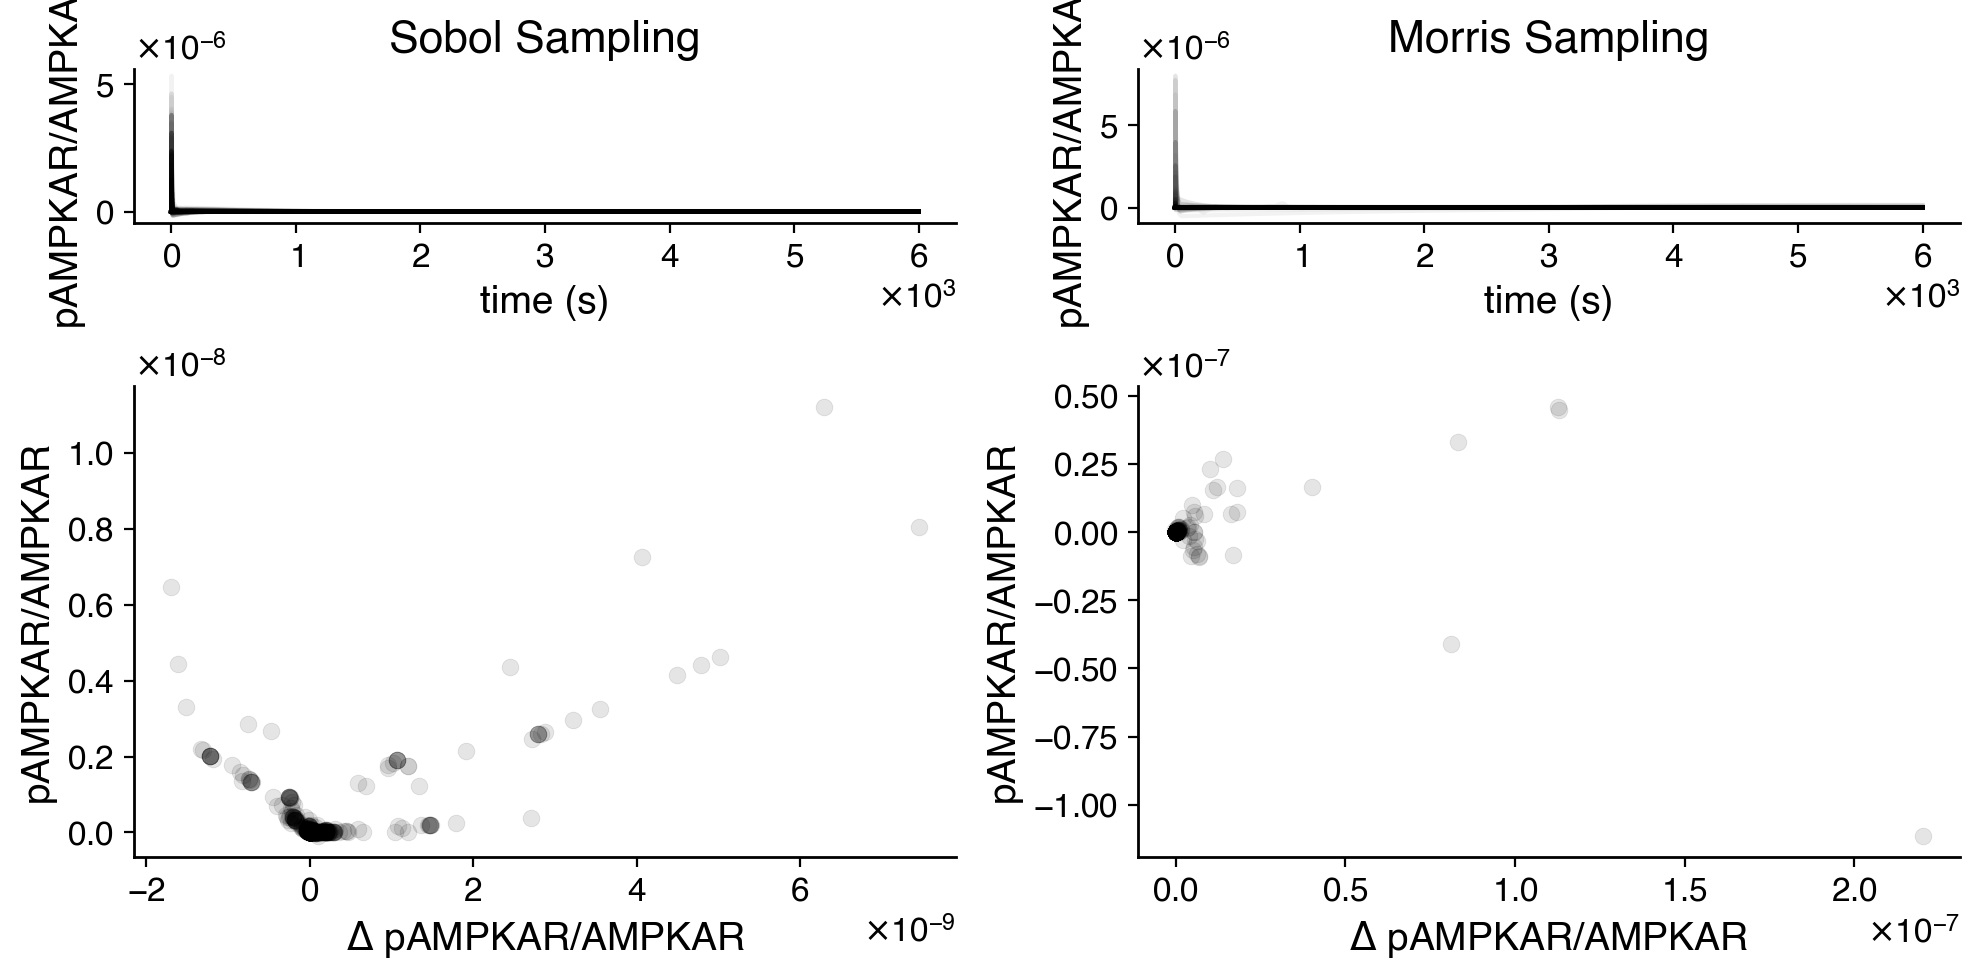

In [11]:
# plot the solutions
# fig, ax = plt.subplots(3, 2, figsize=(10,10))
# f, (a0, a1) = plt.subplots(1, 2, height_ratios=[3, 1])
fig, ax = plt.subplot_mosaic([['traj A', 'traj B'],
     ['scat A', 'scat B'],
     ['scat A', 'scat B']],figsize=(10,5))
for sol in sols_sobol:
    traj = np.vstack((sol[1].view(problem_ode.state_dtype)['pAMPKAR']/sol[1].view(problem_ode.state_dtype)['AMPKAR'],
                      sol[2].view(problem_ode.state_dtype)['pAMPKAR']/sol[2].view(problem_ode.state_dtype)['AMPKAR']))
    ax['traj A'].plot(np.hstack((tvals, tvals[-1]+tvals)), traj, color='k', alpha=0.05)
    ax['scat A'].scatter(sol[0][1], sol[0][0], color='k', alpha=0.1)
    

for sol in sols_morris:
    traj = np.vstack((sol[1].view(problem_ode.state_dtype)['pAMPKAR']/sol[1].view(problem_ode.state_dtype)['AMPKAR'],
                      sol[2].view(problem_ode.state_dtype)['pAMPKAR']/sol[2].view(problem_ode.state_dtype)['AMPKAR']))
    ax['traj B'].plot(np.hstack((tvals, tvals[-1]+tvals)), traj, color='k', alpha=0.05)
    ax['scat B'].scatter(sol[0][1], sol[0][0], color='k', alpha=0.1)


# plot formatting
ax['traj A'].set_xlabel('time (s)')
ax['traj A'].set_ylabel('pAMPKAR/AMPKAR')
ax['traj A'].set_title('Sobol Sampling')

ax['scat A'].set_xlabel('$\Delta$ pAMPKAR/AMPKAR')
ax['scat A'].set_ylabel('pAMPKAR/AMPKAR')

ax['traj B'].set_xlabel('time (s)')
ax['traj B'].set_ylabel('pAMPKAR/AMPKAR')
ax['traj B'].set_title('Morris Sampling')

ax['scat B'].set_xlabel('$\Delta$ pAMPKAR/AMPKAR')
ax['scat B'].set_ylabel('pAMPKAR/AMPKAR')
fig.savefig('./MM_double_mech/bounds_test.pdf')

In [17]:
# now run the model with the Sobol set of samples
# generate samples using the Saltelli and Morris sampling methods
param_vals_sobol = sobol_samp.sample(problem_90, 2048, calc_second_order=True, seed=seed)
param_vals_morris = morris_samp.sample(problem_90, 2048, seed=seed)
tstart = time.time()
sobol_outputs = [single_model_eval(p_set, problem_ode, 
                      solver, set_init_conds(problem_ode, state_names), 
                      tvals, state_names)[0] for p_set in param_vals_sobol]
tend = time.time()
print('Simulating the {} Sobol parameter sets took {} seconds'.format(param_vals_sobol.shape[0], tend-tstart))

np.save('./MM_double_mech/20230327_GSA_MM_double_mech_sobol_samples', np.array(sobol_outputs))

Simulating the 61440 Sobol parameter sets took 303.307186126709 seconds


In [18]:
# And the Morris set of samples
tstart = time.time()
morris_outputs = [single_model_eval(p_set, problem_ode, 
                      solver, set_init_conds(problem_ode, state_names), 
                      tvals, state_names)[0] for p_set in param_vals_morris]
tend = time.time()
print('Simulating the {} Morris parameter sets took {} seconds'.format(param_vals_morris.shape[0], tend-tstart))

np.save('./MM_double_mech/20230327_GSA_MM_double_mech_morris_samples', np.array(morris_outputs))

Simulating the 30720 Morris parameter sets took 152.17496919631958 seconds


In [20]:
# convert lists to numpy arrays and remove extra dimension
m_outputs_np = np.squeeze(np.array(morris_outputs))
s_outputs_np = np.squeeze(np.array(sobol_outputs))

# compute sensitivity indices
Si_morris_ss = morris_analyze.analyze(problem_90, param_vals_morris, m_outputs_np[:,0])
Si_morris_delta = morris_analyze.analyze(problem_90, param_vals_morris, m_outputs_np[:,1])
Si_sobol_ss = sobol_analyze.analyze(problem_90, s_outputs_np[:,0], calc_second_order=False)
Si_sobol_delta = sobol_analyze.analyze(problem_90, s_outputs_np[:,1], calc_second_order=False)

In [22]:
# sort sobol indices by ST
dtype = [('name', 'U10'), ('S1', float), ('S1_conf', float), ('ST', float), ('ST_conf', float)]

Si_sobol_ss_sorted = np.array([(name, S1, S1_conf, ST, ST_conf) for 
                               name, S1, S1_conf, ST, ST_conf in zip(param_names, Si_sobol_ss['S1'], Si_sobol_ss['S1_conf'], 
                                                                     Si_sobol_ss['ST'], Si_sobol_ss['ST'])], dtype=dtype)
Si_sobol_ss_sorted = np.sort(Si_sobol_ss_sorted, order='S1')[::-1]

Si_sobol_delta_sorted = np.array([(name, S1, S1_conf, ST, ST_conf) for 
                               name, S1, S1_conf, ST, ST_conf in zip(param_names, Si_sobol_delta['S1'], Si_sobol_delta['S1_conf'], 
                                                                     Si_sobol_delta['ST'], Si_sobol_delta['ST'])], dtype=dtype)
Si_sobol_delta_sorted = np.sort(Si_sobol_delta_sorted, order='S1')[::-1]

# sort Morris indices by mu_star
dtype = [('name', 'S10'), ('mu_star', float), ('sigma', float), ('mu', float), ('mu_star_conf', float)]

Si_morris_ss_sorted = np.array([(name, mu_star, sigma, mu, mu_star_conf) for 
                               name, mu_star, sigma, mu, mu_star_conf in zip(param_names, Si_morris_ss['mu_star'], Si_morris_ss['sigma'], 
                                                                     Si_morris_ss['mu'], Si_morris_ss['mu_star_conf'])], dtype=dtype)
Si_morris_ss_sorted = np.sort(Si_morris_ss_sorted, order='mu_star')

Si_morris_delta_sorted = np.array([(name, mu_star, sigma, mu, mu_star_conf) for 
                               name, mu_star, sigma, mu, mu_star_conf in zip(param_names, Si_morris_delta['mu_star'], Si_morris_delta['sigma'], 
                                                                     Si_morris_delta['mu'], Si_morris_delta['mu_star_conf'])], dtype=dtype)
Si_morris_delta_sorted = np.sort(Si_morris_delta_sorted, order='mu_star')

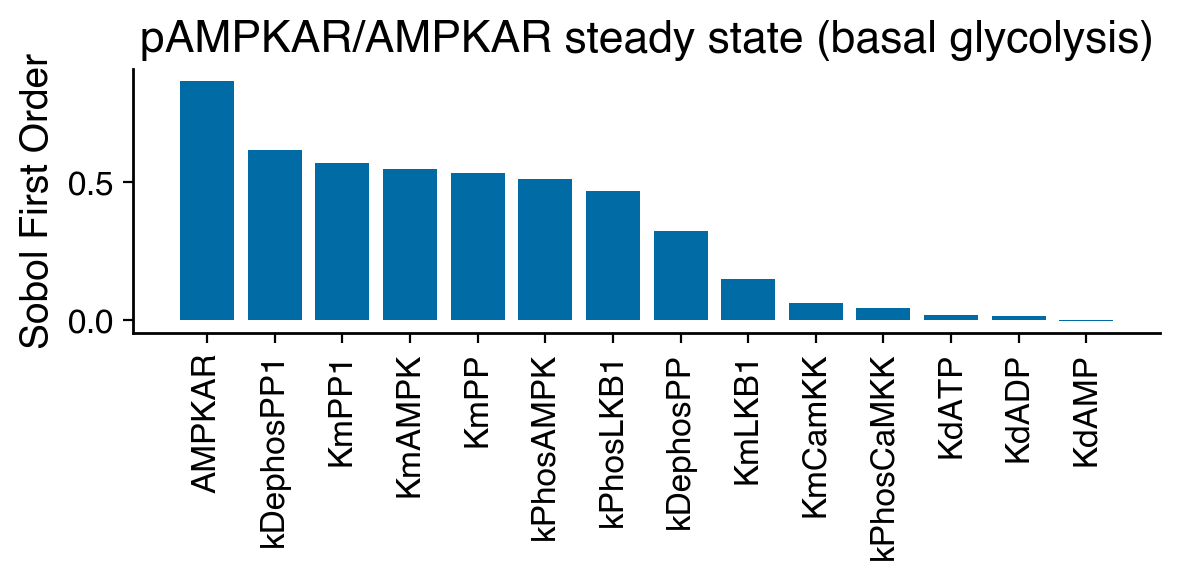

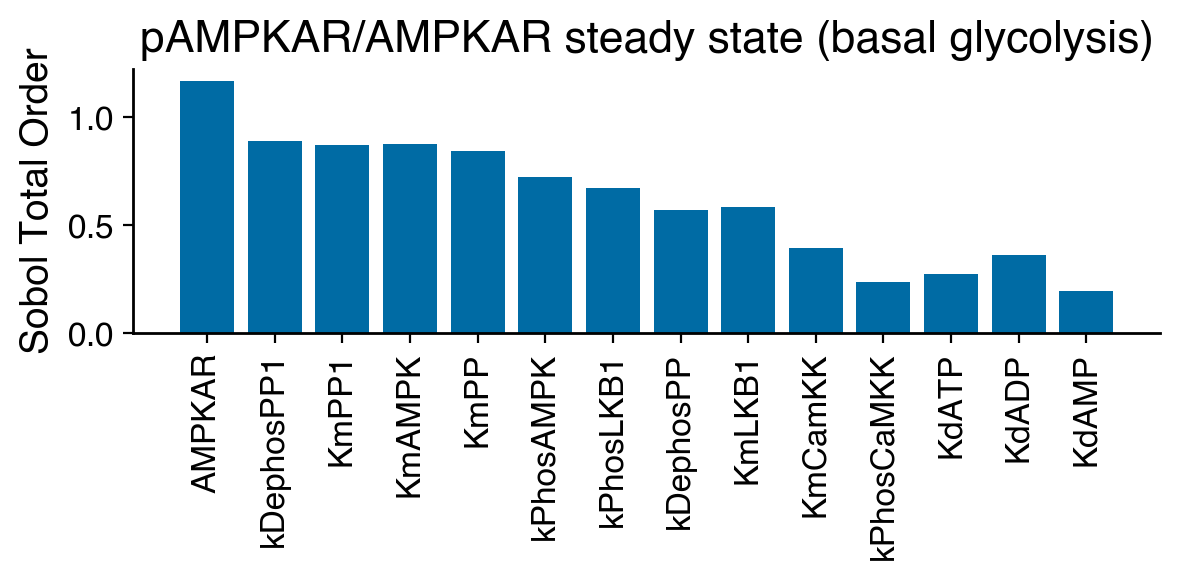

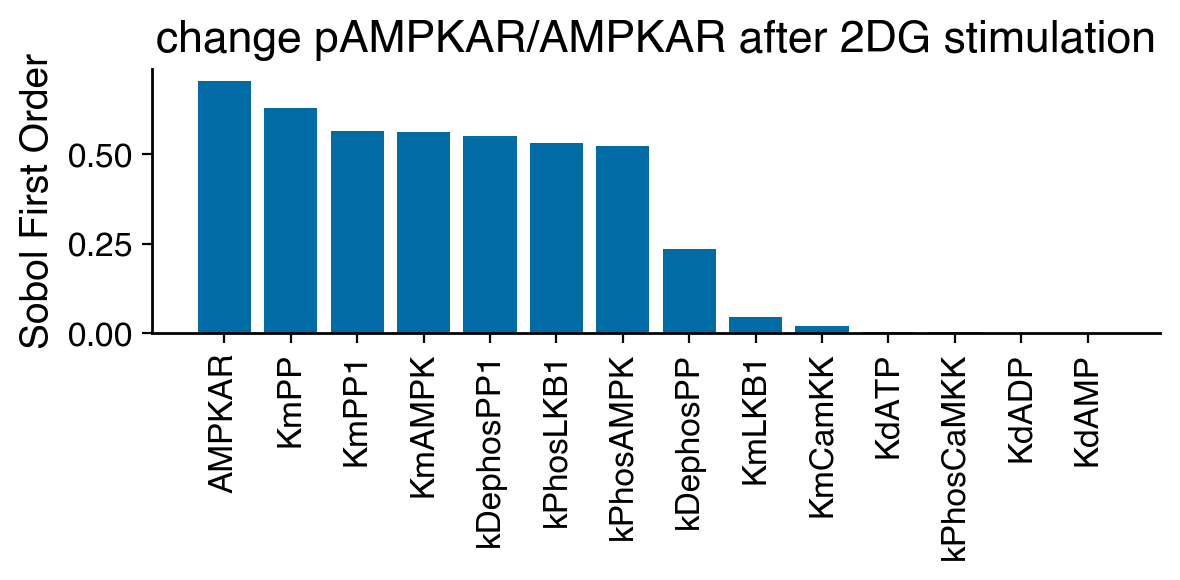

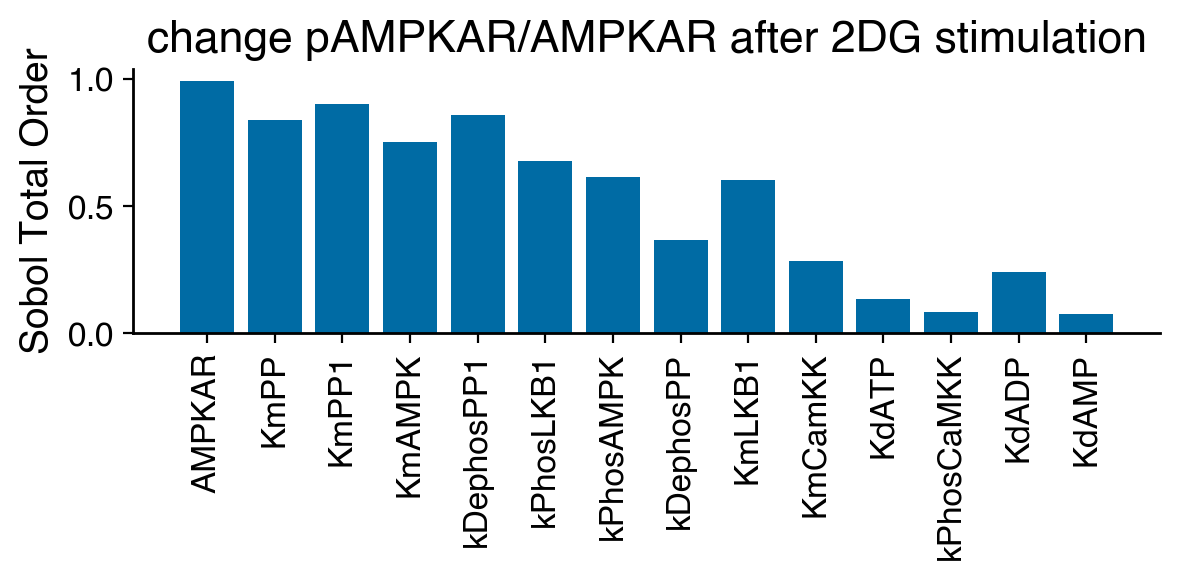

In [25]:
fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,14), Si_sobol_ss_sorted['S1'],
        # yerr=Si_sobol_ss_sorted['S1_conf'],
        log=False)
plt.xticks(np.arange(0,14), Si_sobol_ss_sorted['name'], rotation='vertical')
plt.ylabel('Sobol First Order')
plt.title('pAMPKAR/AMPKAR steady state (basal glycolysis)')
fig.savefig('./MM_double_mech/GSA_MM_double_mech_S1_ss.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,14), Si_sobol_ss_sorted['ST'],
        # yerr=Si_sobol_ss_sorted['ST_conf'],
        log=False)
plt.xticks(np.arange(0,14), Si_sobol_ss_sorted['name'], rotation='vertical')
plt.ylabel('Sobol Total Order')
plt.title('pAMPKAR/AMPKAR steady state (basal glycolysis)')
fig.savefig('./MM_double_mech/GSA_MM_double_mech_ST_ss.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,14), Si_sobol_delta_sorted['S1'],
        # yerr=Si_sobol_delta_sorted['S1_conf'],
        log=False)
plt.xticks(np.arange(0,14), Si_sobol_delta_sorted['name'], rotation='vertical')
plt.ylabel('Sobol First Order')
plt.title('change pAMPKAR/AMPKAR after 2DG stimulation')
fig.savefig('./MM_double_mech/GSA_MM_double_mech_S1_delta.pdf')
plt.show()

fig, ax = plt.subplots(figsize=(6,3))
ax.bar(np.arange(0,14), Si_sobol_delta_sorted['ST'],
        # yerr=Si_sobol_delta_sorted['ST_conf'],
        log=False)
plt.xticks(np.arange(0,14), Si_sobol_delta_sorted['name'], rotation='vertical')
plt.ylabel('Sobol Total Order')
plt.title('change pAMPKAR/AMPKAR after 2DG stimulation')
fig.savefig('./MM_double_mech/GSA_MM_double_mech_ST_delta.pdf')
plt.show()

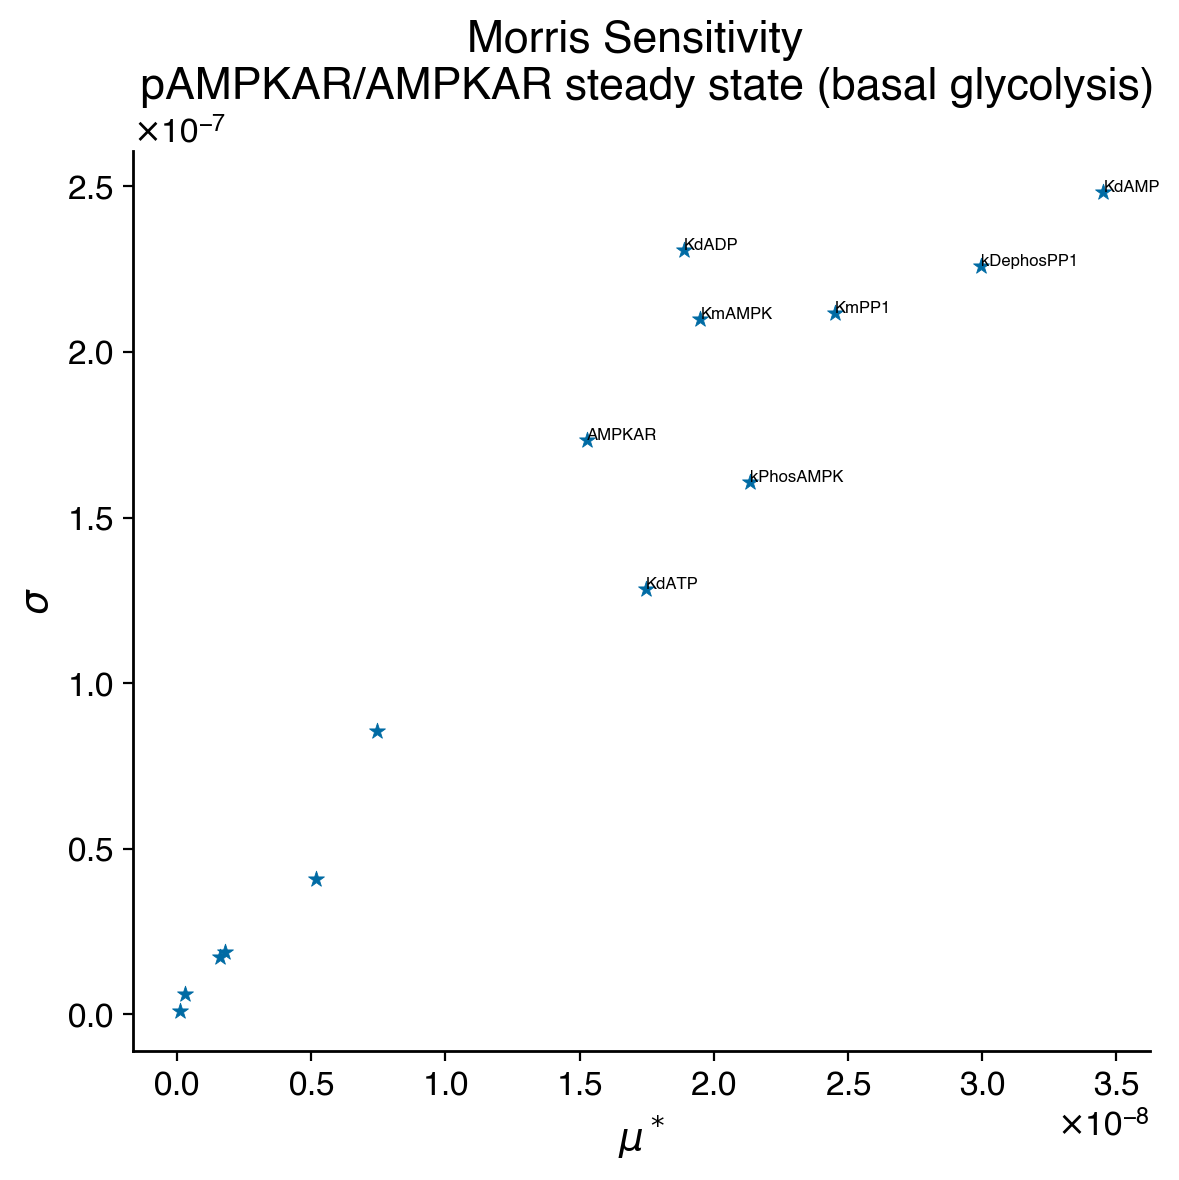

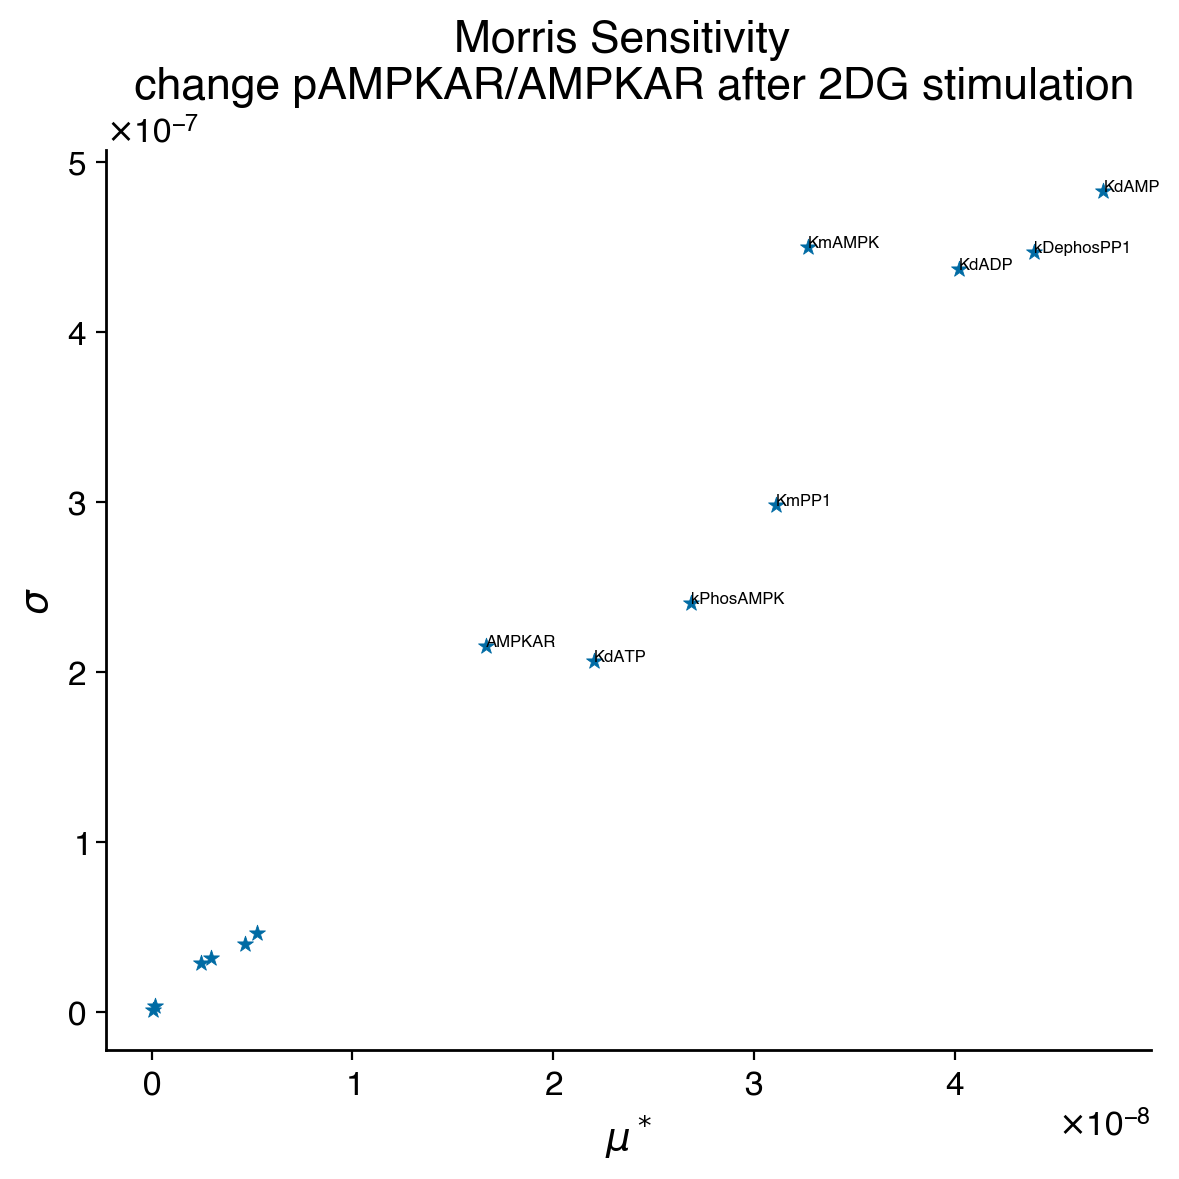

In [27]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(Si_morris_ss_sorted['mu_star'], Si_morris_ss_sorted['sigma'], marker='*',
           )
# ax.plot([0.05, 0.05], [0, 10], 'r', linewidth=1)
# ax.set_xscale('log')
# ax.set_yscale('log')

for i, name_mu_star in enumerate(zip(Si_morris_ss['names'], Si_morris_ss['mu_star'])):
    if name_mu_star[1] >= 1.0e-8:
        ax.annotate(name_mu_star[0], (name_mu_star[1], Si_morris_ss['sigma'][i]), fontsize=6)

ax.set_ylabel('$\sigma$')
ax.set_xlabel('$\mu^*$')
ax.set_title('Morris Sensitivity \n pAMPKAR/AMPKAR steady state (basal glycolysis)')
fig.savefig('./MM_double_mech/GSA_MM_double_mech_morris_ss.pdf')

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(Si_morris_delta_sorted['mu_star'], Si_morris_delta_sorted['sigma'], marker='*',
           )
# ax.plot([0.05, 0.05], [0, 1e-10], 'r', linewidth=1)
# ax.set_xscale('log')
# ax.set_yscale('log')

for i, name_mu_star in enumerate(zip(Si_morris_delta['names'], Si_morris_delta['mu_star'])):
    if name_mu_star[1] >= 1.0e-8:
        ax.annotate(name_mu_star[0], (name_mu_star[1], Si_morris_delta['sigma'][i]), fontsize=6)

ax.set_ylabel('$\sigma$')
ax.set_xlabel('$\mu^*$')
ax.set_title('Morris Sensitivity \n change pAMPKAR/AMPKAR after 2DG stimulation')
fig.savefig('./MM_double_mech/GSA_MM_double_mech_morris_delta.pdf')
